C:\Users\HUU THUC\AppData\Local\Temp\ipykernel_6744\3492794245.py:40: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_month['month'] = pd.Categorical(df_month['month'], categories=months_order, ordered=True)


TỔNG DOANH THU TOÀN DOANH NGHIỆP: $497,538,851.56


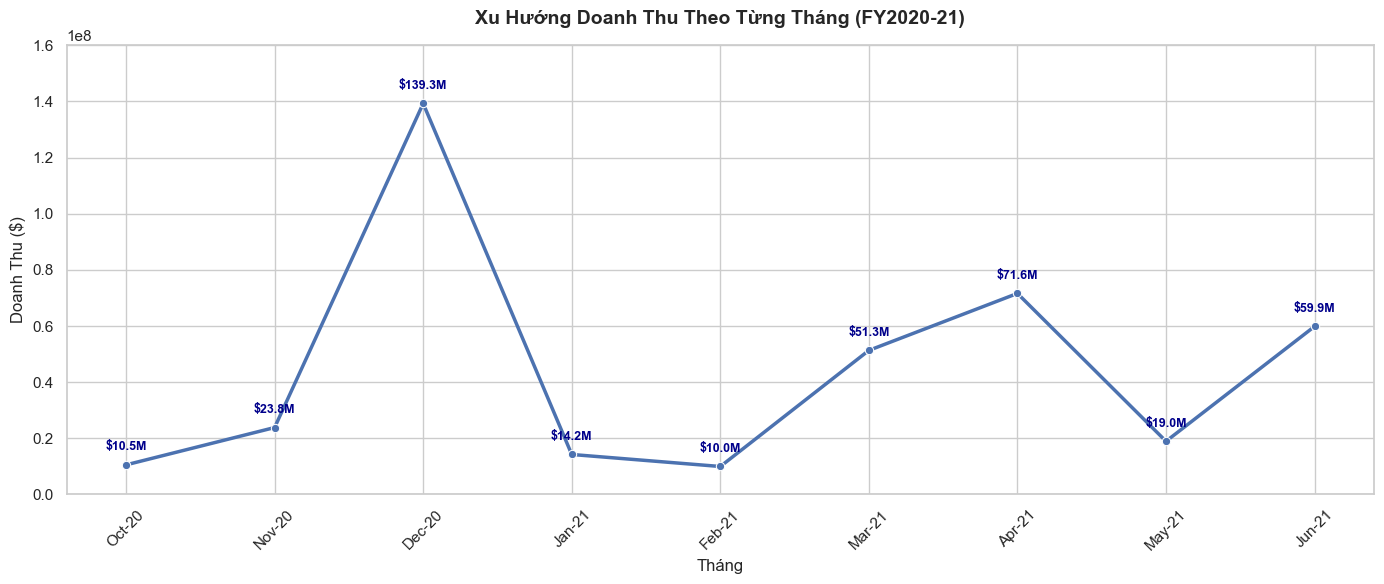

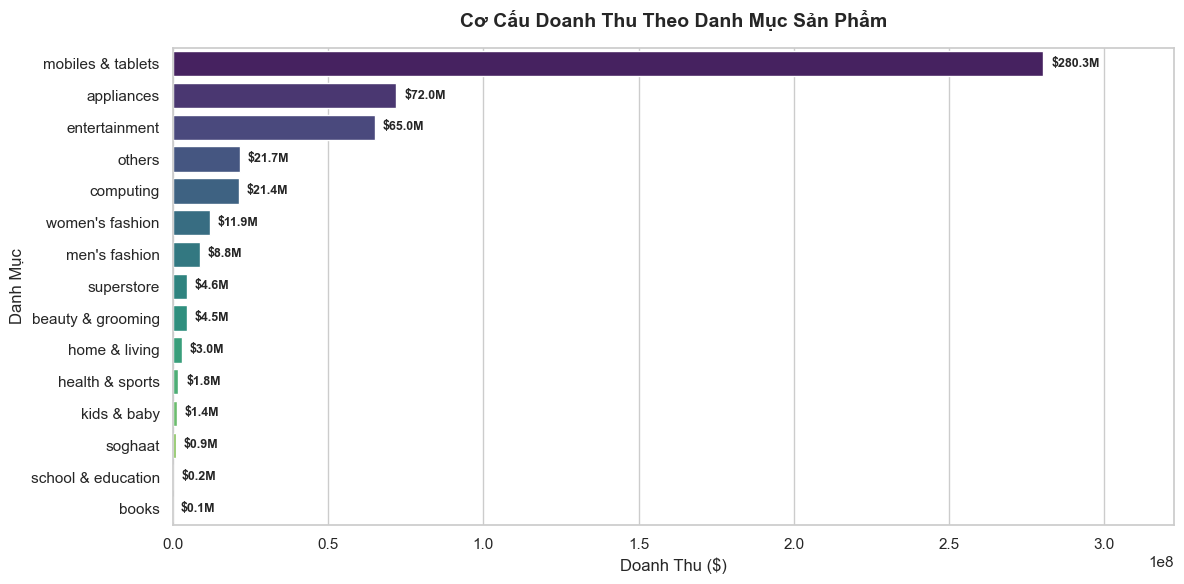

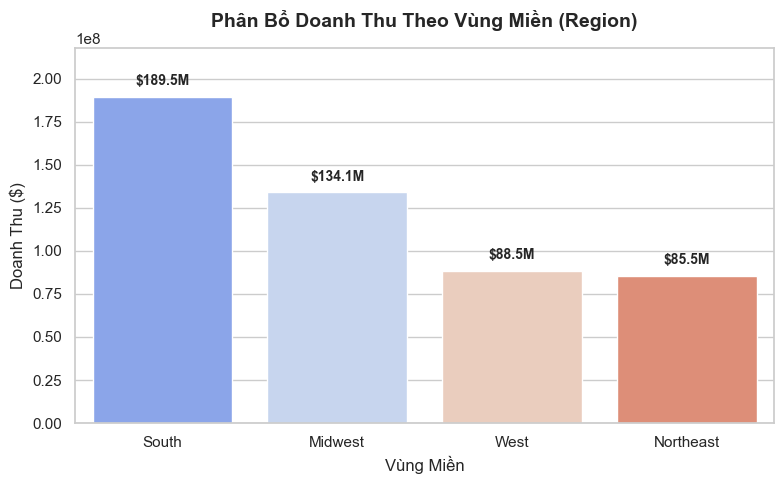

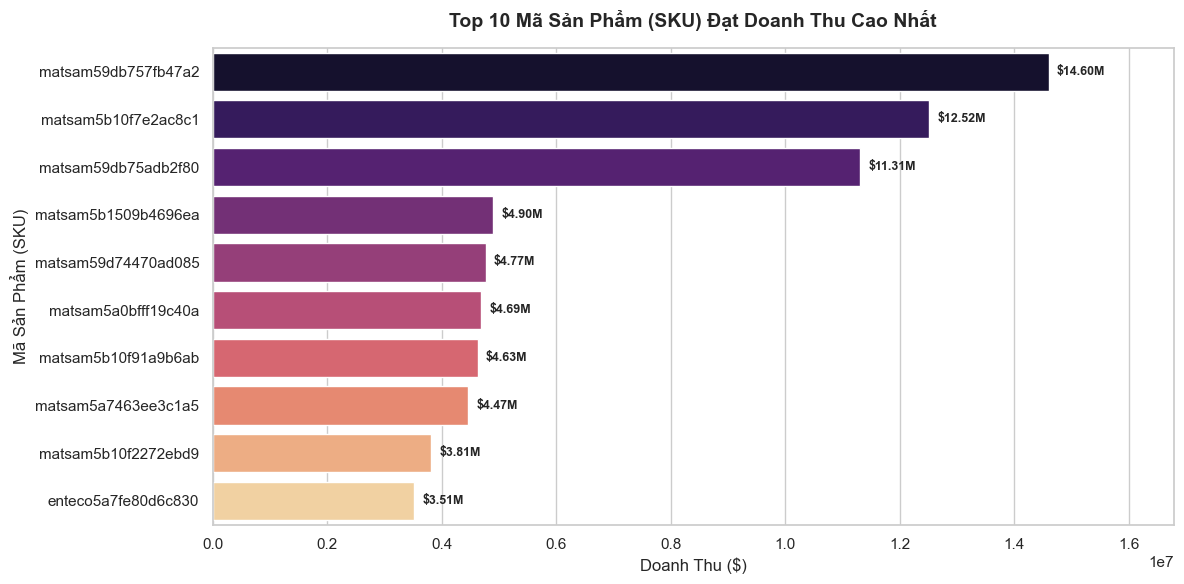

In [ ]:
# ############################################################################
# DASHBOARD 1: TỔNG QUAN HOẠT ĐỘNG KINH DOANH & DOANH THU 
# Sinh viên thực hiện: Nguyễn Hữu Thức  
# Trường: FPT Polytechnic (Ho Chi Minh City)  
# ############################################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế giao diện chung cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

# ## 1. ĐỌC DỮ LIỆU (AGGREGATES)

df_category = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/sales_by_category.csv")
df_month = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/sales_by_month.csv")
df_region = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/sales_by_region.csv")
df_year = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/sales_by_year.csv")
df_top10 = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/top_10_products.csv")

# HÀM BỔ SUNG: Ép kiểu dữ liệu 'revenue' về dạng số
def clean_revenue(df):
    if df['revenue'].dtype == 'object':
        df['revenue'] = df['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
    return df

df_category = clean_revenue(df_category)
df_month = clean_revenue(df_month)
df_region = clean_revenue(df_region)
df_year = clean_revenue(df_year)
df_top10 = clean_revenue(df_top10)

# Sắp xếp lại dữ liệu tháng theo đúng trình tự thời gian
months_order = ['Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 
                'Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21']
df_month['month'] = pd.Categorical(df_month['month'], categories=months_order, ordered=True)
df_month = df_month.sort_values('month')

# ## 2. TÍNH TOÁN CÁC CHỈ SỐ KPI ĐỂ TRÌNH BÀY

total_revenue = df_year['revenue'].sum()
print("===========================================")
print(f"TỔNG DOANH THU TOÀN DOANH NGHIỆP: ${total_revenue:,.2f}")
print("===========================================")

# ## 3. VẼ CÁC BIỂU ĐỒ HIỆN THỰC HÓA DASHBOARD

# --- Biểu đồ 1: Xu hướng doanh thu theo tháng ---
plt.figure(figsize=(14, 6))
line_plot = sns.lineplot(data=df_month, x='month', y='revenue', marker='o', color='b', linewidth=2.5)

offset = df_month['revenue'].max() * 0.03

for i in range(len(df_month)):
    row = df_month.iloc[i]
    if pd.notna(row['revenue']) and row['revenue'] > 0:
        val_in_m = row['revenue'] / 1000000
        
        plt.text(x=row['month'], 
                 y=row['revenue'] + offset, 
                 s=f"${val_in_m:.1f}M", 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue')

plt.title('Xu Hướng Doanh Thu Theo Từng Tháng (FY2020-21)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh Thu ($)', fontsize=12)
plt.xticks(rotation=45)

plt.ylim(0, df_month['revenue'].max() * 1.15) 

plt.tight_layout()
plt.savefig('sales_trend_month.png')
plt.show()

# --- Biểu đồ 2: Cơ cấu doanh thu theo Danh mục sản phẩm ---
plt.figure(figsize=(12, 6))
df_category_sorted = df_category.sort_values(by='revenue', ascending=False)
bar_plot2 = sns.barplot(data=df_category_sorted, x='revenue', y='category', hue='category', palette='viridis', legend=False)

# Điền số liệu ở cuối mỗi cột ngang
for patch in bar_plot2.patches:
    width = patch.get_width()
    if width > 0:
        val_in_m = width / 1000000
        bar_plot2.text(x=width + (total_revenue * 0.005), 
                       y=patch.get_y() + patch.get_height() / 2, 
                       s=f"${val_in_m:.1f}M", 
                       ha='left', va='center', fontsize=9, fontweight='bold')

plt.title('Cơ Cấu Doanh Thu Theo Danh Mục Sản Phẩm', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Doanh Thu ($)', fontsize=12)
plt.ylabel('Danh Mục', fontsize=12)
plt.xlim(0, df_category_sorted['revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

# --- Biểu đồ 3: Phân bổ doanh thu theo Vùng địa lý ---
plt.figure(figsize=(8, 5))
df_region_sorted = df_region.sort_values(by='revenue', ascending=False)
bar_plot3 = sns.barplot(data=df_region_sorted, x='region', y='revenue', hue='region', palette='coolwarm', legend=False)

# Điền số liệu ngay trên đầu mỗi cột dọc
for patch in bar_plot3.patches:
    height = patch.get_height()
    if height > 0:
        val_in_m = height / 1000000
        bar_plot3.text(x=patch.get_x() + patch.get_width() / 2, 
                       y=height + (total_revenue * 0.01), 
                       s=f"${val_in_m:.1f}M", 
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Phân Bổ Doanh Thu Theo Vùng Miền (Region)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vùng Miền', fontsize=12)
plt.ylabel('Doanh Thu ($)', fontsize=12)
plt.ylim(0, df_region_sorted['revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

# --- Biểu đồ 4: Top 10 mã sản phẩm mang lại doanh thu cao nhất ---
plt.figure(figsize=(12, 6))
df_top10_sorted = df_top10.sort_values(by='revenue', ascending=False)
bar_plot4 = sns.barplot(data=df_top10_sorted, x='revenue', y='sku', hue='sku', palette='magma', legend=False)

# Điền số liệu ở cuối mỗi cột ngang của Top 10 sản phẩm
for patch in bar_plot4.patches:
    width = patch.get_width()
    if width > 0:
        val_in_m = width / 1000000
        bar_plot4.text(x=width + (df_top10_sorted['revenue'].max() * 0.01), 
                       y=patch.get_y() + patch.get_height() / 2, 
                       s=f"${val_in_m:.2f}M", 
                       ha='left', va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 Mã Sản Phẩm (SKU) Đạt Doanh Thu Cao Nhất', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Doanh Thu ($)', fontsize=12)
plt.ylabel('Mã Sản Phẩm (SKU)', fontsize=12)
plt.xlim(0, df_top10_sorted['revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('top_10_products.png')
plt.show()